# Creating visualizations for our Report

## Load Imports

In [1]:
import pandas as pd
import numpy as np
import optuna
import jax.numpy as jnp
from tqdm.notebook import tqdm
import os


In [19]:
import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))
from src.viz.report import plot_release_frame_exemplar

In [3]:
%load_ext autoreload
%autoreload 2

## Load Data

In [17]:
traj_df = pd.read_parquet('../data/processed/traj_features/traj_01.18.2016.GSW.at.CLE_21500622.parquet')
traj_df.columns

Index(['GAME_ID', 'SHOT_EVENT_ID', 'tracking_event_id', 'event_list_idx',
       'PERIOD', 'game_clock', 'PLAYER_ID', 'TEAM_ID', 'flipped_coordinates',
       'ball_x_traj', 'ball_y_traj', 'off1_pid', 'off1_x_traj', 'off1_y_traj',
       'off1_q_traj', 'def1_pid', 'def1_x_traj', 'def1_y_traj', 'off2_pid',
       'off2_x_traj', 'off2_y_traj', 'off2_q_traj', 'def2_pid', 'def2_x_traj',
       'def2_y_traj', 'off3_pid', 'off3_x_traj', 'off3_y_traj', 'off3_q_traj',
       'def3_pid', 'def3_x_traj', 'def3_y_traj', 'off4_pid', 'off4_x_traj',
       'off4_y_traj', 'off4_q_traj', 'def4_pid', 'def4_x_traj', 'def4_y_traj',
       'off5_pid', 'off5_x_traj', 'off5_y_traj', 'off5_q_traj', 'def5_pid',
       'def5_x_traj', 'def5_y_traj', 'release_frame_global_idx',
       'pbp_frame_global_idx', 'local_release_idx', 'local_pbp_idx',
       'ball_z_traj', 'SHOT_MADE_FLAG'],
      dtype='object')

In [70]:
traj_df.head()

,GAME_ID,SHOT_EVENT_ID,tracking_event_id,event_list_idx,PERIOD,game_clock,PLAYER_ID,TEAM_ID,flipped_coordinates,ball_x_traj,...,off5_q_traj,def5_pid,def5_x_traj,def5_y_traj,release_frame_global_idx,pbp_frame_global_idx,local_release_idx,local_pbp_idx,ball_z_traj,SHOT_MADE_FLAG
0,21500622,8,1,0,1,617,201567,1610612739,0,"[20.40327, 20.27989, 20.16353, 20.0552, 19.955...",...,"[0.8042342662811279, 0.8042342662811279, 0.804...",203084,"[-0.515509999999999, -0.7155699999999996, -0.9...","[3.01079, 2.89893, 2.7879500000000004, 2.68778...",50,149,50,149,"[3.54135, 3.6859, 3.80584, 3.89686, 3.95463, 3...",0
1,21500622,10,2,1,1,610,202691,1610612744,1,"[-12.015419999999999, -12.03564, -12.323990000...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",202389,"[-2.5867499999999986, -2.617609999999999, -2.6...","[21.301969999999997, 21.106830000000002, 20.90...",258,334,75,151,"[8.92556, 9.33024, 9.70121, 10.03012, 10.08909...",1
2,21500622,28,17,4,1,516,2544,1610612739,0,"[4.926300000000001, 5.964169999999999, 7.05731...",...,"[1.3832465410232544, 1.3832465410232544, 1.417...",203084,"[0.6417499999999983, 0.6631099999999996, 0.676...","[11.754650000000002, 11.429739999999999, 11.11...",271,359,75,163,"[7.00069, 6.94837, 6.91019, 6.84764, 6.66811, ...",0
3,21500622,30,20,7,1,503,203110,1610612744,1,"[-12.307899999999997, -12.209679999999999, -12...",...,"[1.1572421789169312, 1.1572421789169312, 1.157...",202389,"[1.4192800000000005, 1.4939299999999989, 1.577...","[7.067409999999995, 7.102639999999994, 7.14706...",241,309,75,143,"[4.38831, 4.63916, 4.61552, 4.80345, 4.82673, ...",0
4,21500622,34,21,8,1,486,101106,1610612744,1,"[-20.913269999999997, -20.941429999999997, -20...",...,"[1.140377402305603, 1.140377402305603, 1.14037...",202389,"[-7.172840000000001, -7.26829, -7.350349999999...","[14.531360000000006, 14.549440000000004, 14.57...",451,520,75,144,"[3.68183, 3.60123, 3.5027, 3.38264, 3.21821, 3...",0


In [18]:
traj_df[['release_frame_global_idx',
       'pbp_frame_global_idx', 'local_release_idx', 'local_pbp_idx', 'ball_z_traj']]

,release_frame_global_idx,pbp_frame_global_idx,local_release_idx,local_pbp_idx,ball_z_traj
0,50,149,50,149,"[3.54135, 3.6859, 3.80584, 3.89686, 3.95463, 3..."
1,258,334,75,151,"[8.92556, 9.33024, 9.70121, 10.03012, 10.08909..."
2,271,359,75,163,"[7.00069, 6.94837, 6.91019, 6.84764, 6.66811, ..."
3,241,309,75,143,"[4.38831, 4.63916, 4.61552, 4.80345, 4.82673, ..."
4,451,520,75,144,"[3.68183, 3.60123, 3.5027, 3.38264, 3.21821, 3..."
...,...,...,...,...,...
105,782,863,75,156,"[3.36312, 3.25274, 3.08078, 2.7625, 2.20123, 1..."
106,274,307,75,108,"[4.09767, 3.88457, 3.33226, 3.32629, 3.04336, ..."
107,302,393,75,166,"[4.36226, 4.42139, 4.36361, 4.31641, 4.32341, ..."
108,236,316,75,155,"[3.96861, 3.90302, 4.02127, 3.8942, 3.44613, 3..."


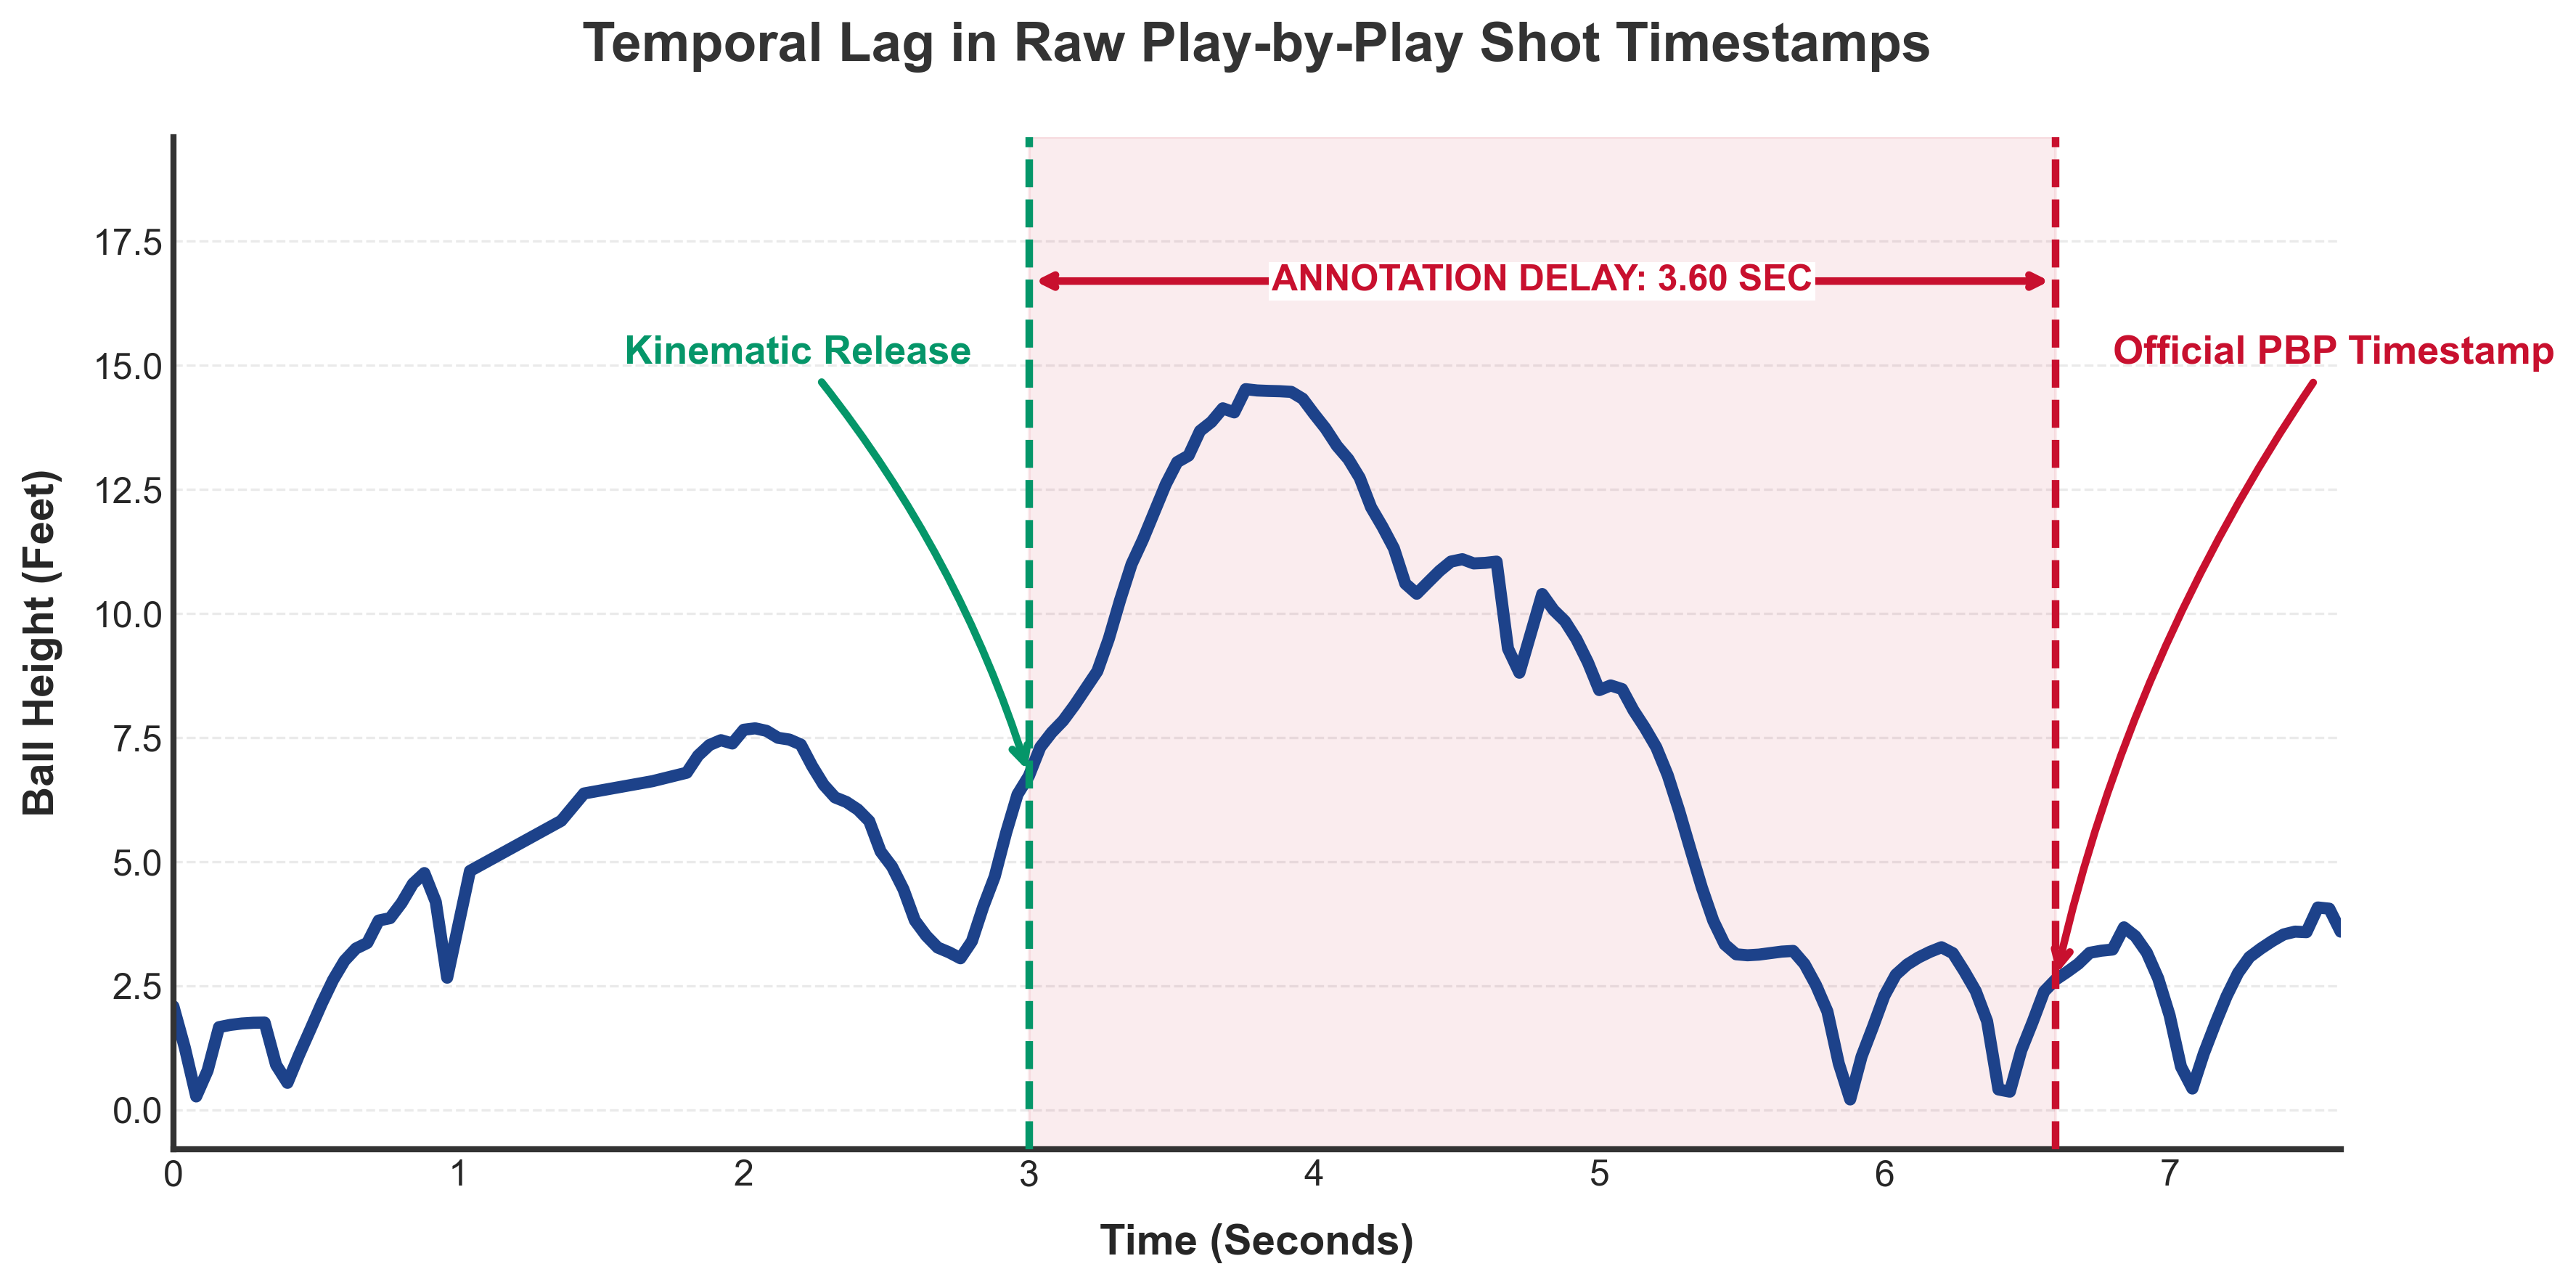

In [69]:
plot_release_frame_exemplar(traj_df.iloc[31])

In [71]:
final_df = pd.read_csv('all_plays_ist_master.csv')

In [72]:
final_df.columns

Index(['Game_File', 'Play_Index', 'GAME_ID', 'SHOT_EVENT_ID', 'PERIOD',
       'GAME_CLOCK', 'Offensive_Team_ID', 'Defensive_Team_ID', 'Shooter_PID',
       'Shot_Dist', 'Is_Three', 'Real_IST', 'Sim_IST', 'Pressure_Prevented',
       'POS_Real_IST', 'POS_Sim_IST', 'Frames_Won', 'Total_Frames',
       'Frame_Win_Rate', 'Offender_1_PID', 'Defender_1_PID', 'Offender_2_PID',
       'Defender_2_PID', 'Offender_3_PID', 'Defender_3_PID', 'Offender_4_PID',
       'Defender_4_PID', 'Offender_5_PID', 'Defender_5_PID', 'Shot_Made'],
      dtype='object')

In [ ]:
avg_real = final_df['Real_IST'].mean()
avg_sim = final_df['Sim_IST'].mean()
percent_reduction = (avg_real - avg_sim) / avg_real